In [1]:
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

In [2]:
INPUT_DIR = "inputs"

# Omentum

In [3]:
adata_an = sc.read_h5ad(os.path.join(INPUT_DIR, "anndatas", 'omentum_reannotated_finely.h5ad'))
adata_nan = sc.read_h5ad(os.path.join(INPUT_DIR, "anndatas", "omentum_raw.h5ad"))

In [4]:
adata_nan.obs["cell_type"] = None
idx = adata_nan.obs_names.isin(adata_an.obs_names)
adata_nan.obs.loc[idx, "cell_type"] = adata_an.obs.loc[adata_nan.obs_names[idx], "cell_type"].values
adata_nan.obs.loc[idx, "cell_type1"] = adata_an.obs.loc[adata_nan.obs_names[idx], "cell_type1"].values

In [ ]:
adata_nan.obs.value_counts(["cell_type", "cell_type1"]).sort_index()

cell_type  cell_type1  
B cells    B cells         374
           CD4+ T cells      0
           CD8+ T cells      0
           CD8+ TRM          0
           CD9+ ATM          0
                          ... 
T cells    cDCs              0
           mNK1 cells        0
           mNK2 cell         0
           mNK3 cells        0
           pDCs              0
Name: count, Length: 319, dtype: int64

In [ ]:
adata_nan.obs["cell_type"].isna().sum()

np.int64(6989)

In [ ]:
adata_nan.obs.value_counts("status")

status
singlet       29613
doublet        3157
unassigned       49
Name: count, dtype: int64

In [8]:
sc.experimental.pp.recipe_pearson_residuals(adata_nan)

sc.pl.pca(
    adata_nan,
    color=["status",],
    # dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    # ncols=2,
    size=2,
)

/opt/miniconda3/envs/sc/lib/python3.13/site-packages/scanpy/plotting/_utils.py:389: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [9]:
sc.pp.neighbors(adata_nan, n_pcs=30, n_neighbors=15)
sc.tl.umap(adata_nan, )
sc.pl.umap(adata_nan, color=["status",])

/opt/miniconda3/envs/sc/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/sc/lib/python3.13/site-packages/scanpy/plotting/_utils.py:389: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [10]:
sc.tl.leiden(adata_nan, flavor="igraph", n_iterations=2, resolution=2)

In [11]:
sc.pl.umap(adata_nan, color=["leiden", "status"])

/opt/miniconda3/envs/sc/lib/python3.13/site-packages/scanpy/plotting/_utils.py:389: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [12]:
vc = adata_nan.obs.value_counts(["leiden", "cell_type"], dropna=False).sort_index()
with pd.option_context('display.max_rows', 200):
    print(vc)

leiden  cell_type     
0       B cells             0
        ECs               709
        FAPs                5
        IGFBP2+ cells       0
        Mesothelial         1
                         ... 
40      NK cells          126
        Plasma cells        0
        Pre-adipocytes      0
        T cells            31
        nan                22
Name: count, Length: 492, dtype: int64


Cohorts: ['Healthy', 'Unhealthy']
  Healthy: 695 / 18442 predicted doublets (3.8%)  threshold=0.2235


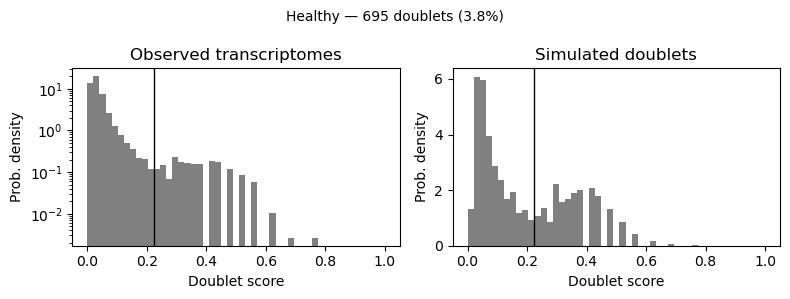

  Unhealthy: 643 / 14377 predicted doublets (4.5%)  threshold=0.2003


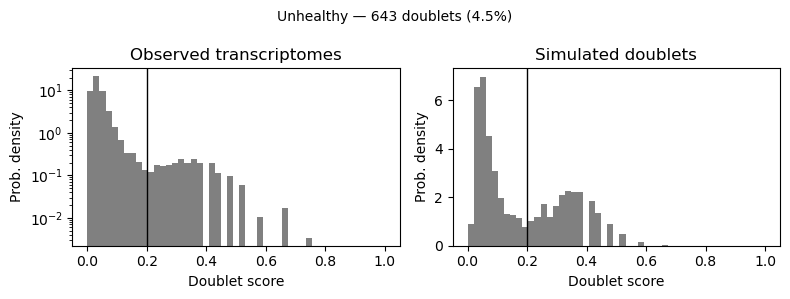

Agreement: Scrublet (transcriptomic) vs souporcell (genetic) — all cells:
scrublet_call  scrublet_doublet  scrublet_singlet    All
status                                                  
doublet                     946              2211   3157
singlet                     391             29222  29613
unassigned                    1                48     49
All                        1338             31481  32819
Per cohort:
Healthy:
scrublet_call  scrublet_doublet  scrublet_singlet    All
status                                                  
doublet                     515              1249   1764
singlet                     180             16471  16651
unassigned                    0                27     27
All                         695             17747  18442
Unhealthy:
scrublet_call  scrublet_doublet  scrublet_singlet    All
status                                                  
doublet                     431               962   1393
singlet                     211        

In [17]:
import scrublet as scr
import scipy.sparse as sp
import numpy as np
import matplotlib.pyplot as plt

# Healthy and Unhealthy cohorts were captured in two separate 10x pools.
# Within each pool, souporcell demultiplexed ~5 individuals by genotype clustering.
# Doublets can only form within the same capture pool, so Scrublet is run
# separately per cohort.
# adata_nan.obs["status"] = souporcell genetic doublet call (independent method).

# Note: scrublet 0.2.3 plot_histogram() creates its own figure — no axes argument.

cohorts = sorted(adata_nan.obs["cohort"].unique())
print(f"Cohorts: {cohorts}")

scrublet_scores     = pd.Series(index=adata_nan.obs_names, dtype=float)
scrublet_calls      = pd.Series(index=adata_nan.obs_names, dtype=bool)
scrublet_thresholds = {}

for i, cohort in enumerate(cohorts):
    mask = adata_nan.obs["cohort"] == cohort
    X = adata_nan[mask].X
    if sp.issparse(X):
        X = X.toarray()

    scrub = scr.Scrublet(X, expected_doublet_rate=0.06, random_state=42)
    scores, calls = scrub.scrub_doublets(
        min_counts=2, min_cells=3, n_prin_comps=30, verbose=False,
    )

    scrublet_scores[adata_nan.obs_names[mask]] = scores
    scrublet_calls[adata_nan.obs_names[mask]]  = calls
    scrublet_thresholds[cohort] = scrub.threshold_

    n_pred = int(calls.sum())
    pct    = 100 * n_pred / int(mask.sum())
    print(f"  {cohort}: {n_pred} / {int(mask.sum())} predicted doublets ({pct:.1f}%)"
          f"  threshold={scrub.threshold_:.4f}")

    # plot_histogram() creates its own figure in scrublet 0.2.3
    fig, axes = scrub.plot_histogram()
    fig.suptitle(f"{cohort} — {n_pred} doublets ({pct:.1f}%)", fontsize=10)
    plt.tight_layout()
    plt.show()

adata_nan.obs["scrublet_score"] = scrublet_scores
adata_nan.obs["scrublet_call"]  = scrublet_calls

# Agreement with souporcell status
print("Agreement: Scrublet (transcriptomic) vs souporcell (genetic) — all cells:")
print(pd.crosstab(
    adata_nan.obs["status"],
    adata_nan.obs["scrublet_call"].map({True: "scrublet_doublet", False: "scrublet_singlet"}),
    margins=True,
))

print("Per cohort:")
for cohort in cohorts:
    mask = adata_nan.obs["cohort"] == cohort
    print(f"{cohort}:")
    print(pd.crosstab(
        adata_nan.obs.loc[mask, "status"],
        adata_nan.obs.loc[mask, "scrublet_call"].map(
            {True: "scrublet_doublet", False: "scrublet_singlet"}),
        margins=True,
    ))



In [15]:
%matplotlib inline

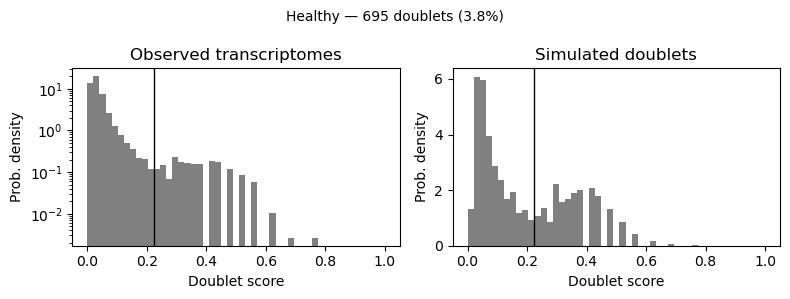

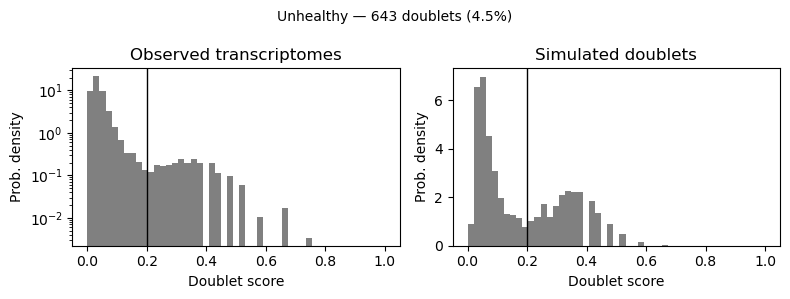

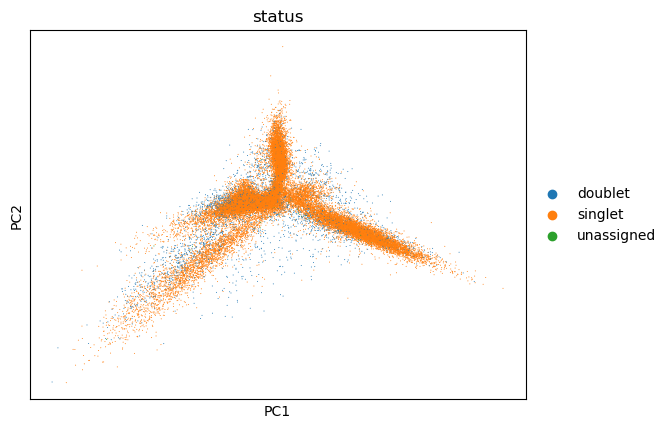

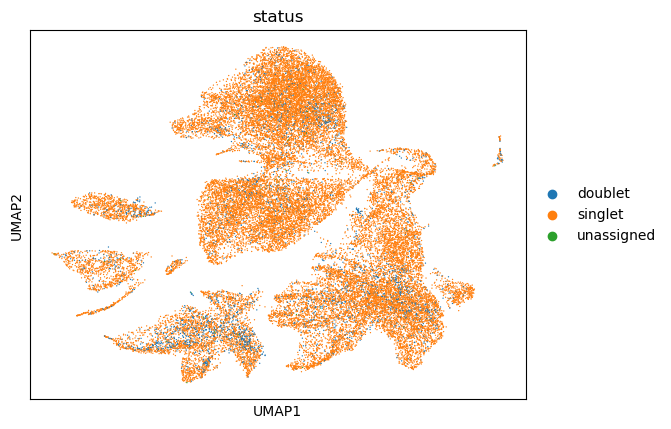

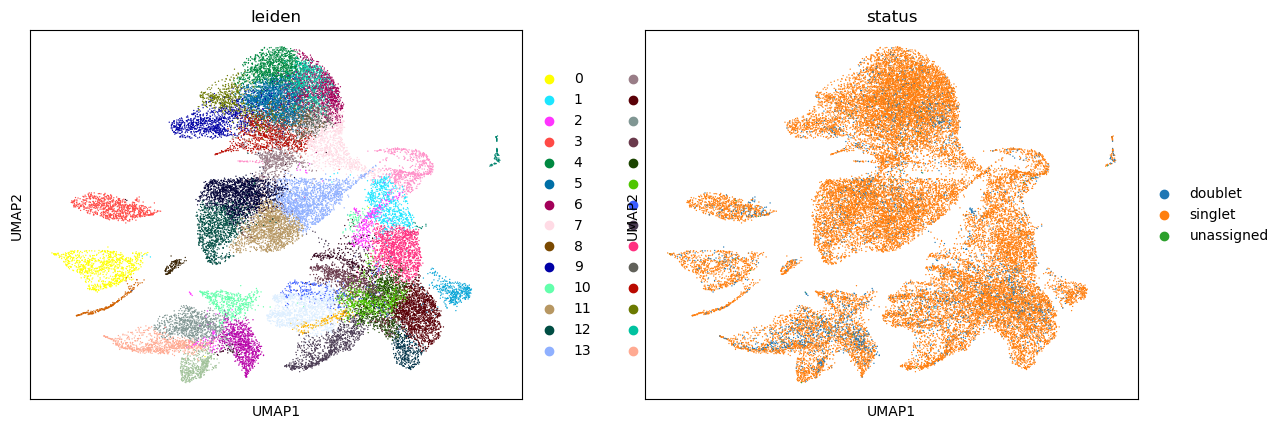

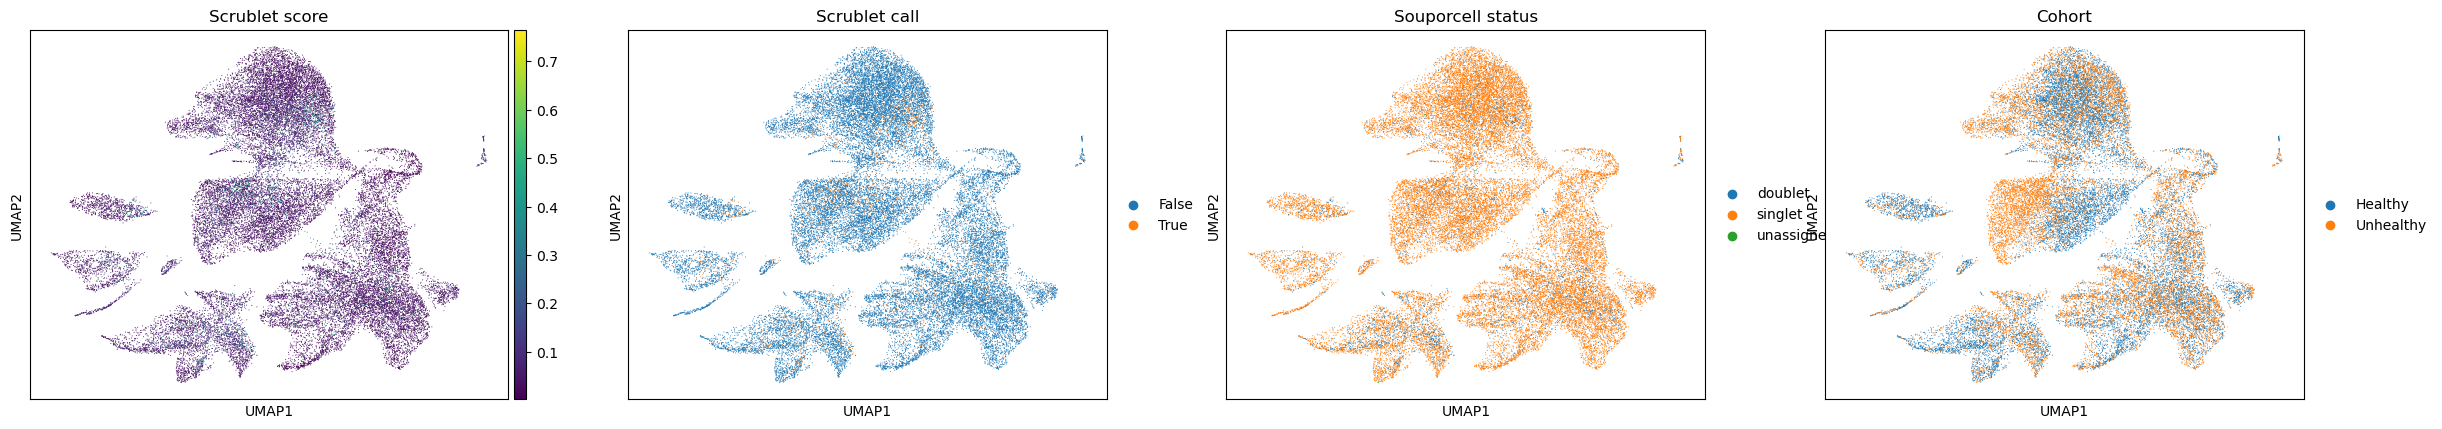

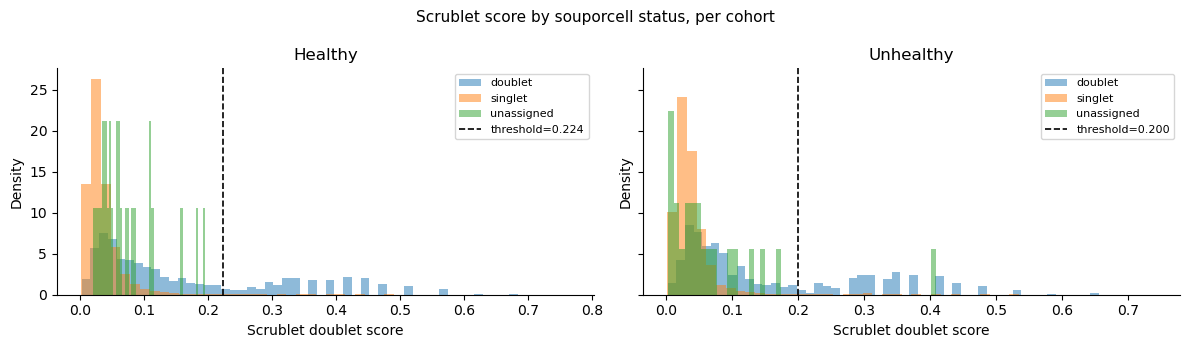

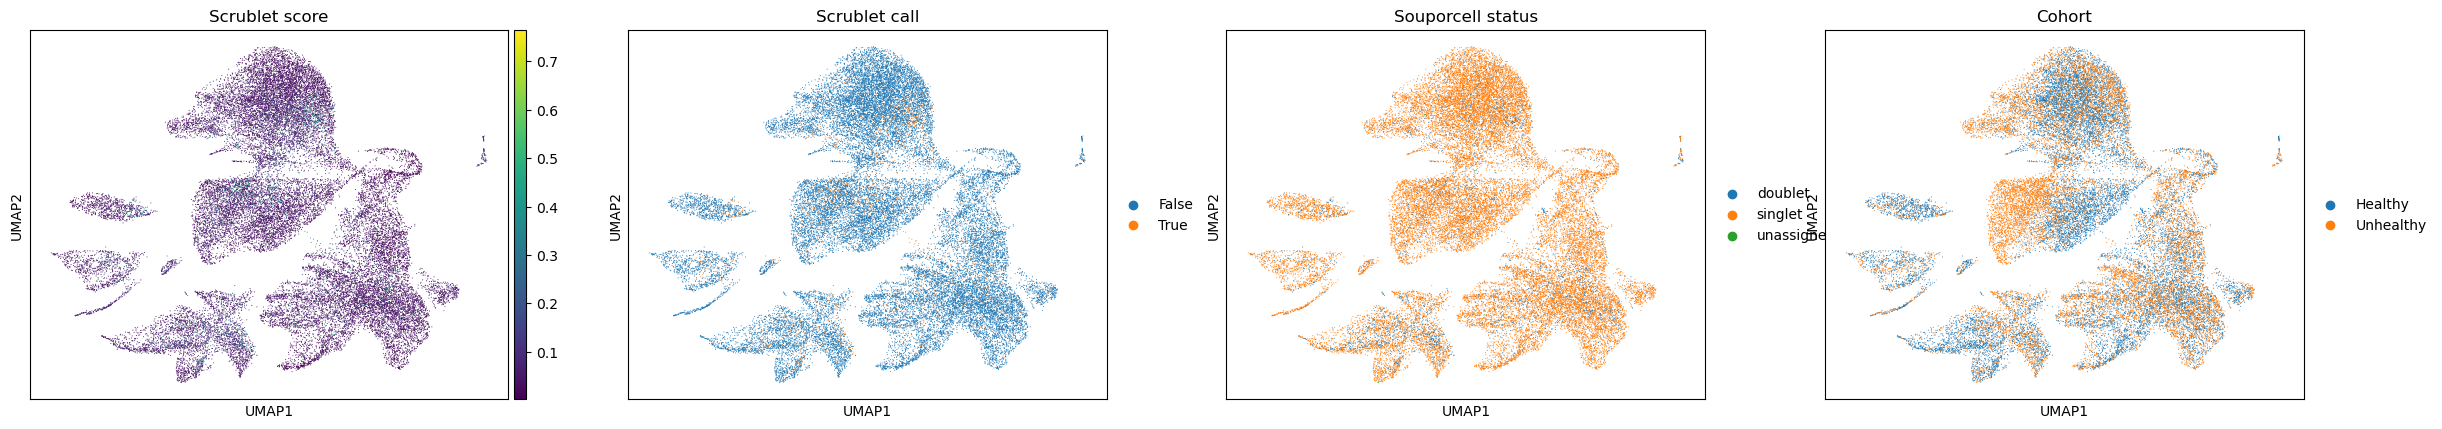

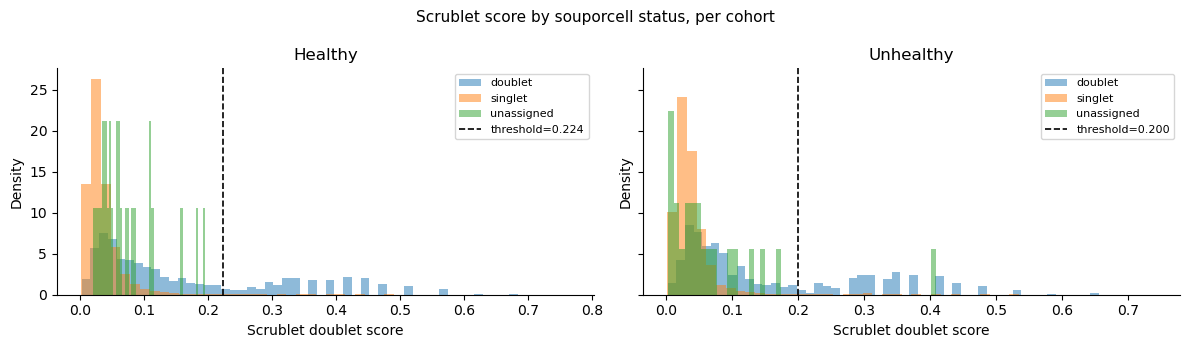

In [16]:
# UMAP
sc.pl.umap(adata_nan,
           color=["scrublet_score", "scrublet_call", "status", "cohort"],
           ncols=4, size=2,
           title=["Scrublet score", "Scrublet call", "Souporcell status", "Cohort"])

# Score distributions by souporcell status, per cohort
fig, axes2 = plt.subplots(1, len(cohorts), figsize=(6 * len(cohorts), 3.5), sharey=True)
for i, cohort in enumerate(cohorts):
    ax   = axes2[i]
    mask = adata_nan.obs["cohort"] == cohort
    sub  = adata_nan.obs.loc[mask]
    for label, grp in sub.groupby("status"):
        ax.hist(grp["scrublet_score"], bins=50, alpha=0.5, label=label, density=True)
    thr = scrublet_thresholds[cohort]
    ax.axvline(thr, color="black", lw=1.2, ls="--", label=f"threshold={thr:.3f}")
    ax.set_xlabel("Scrublet doublet score")
    ax.set_ylabel("Density")
    ax.set_title(cohort)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
fig.suptitle("Scrublet score by souporcell status, per cohort", fontsize=11)
plt.tight_layout()
plt.show()


In [27]:
leiden_clusters = {}

for leiden_cluster, counts in vc.groupby(level=0):
    
    percents = counts / counts.sum()
    
    leiden_celltype = "/".join(percents[percents > 0.3].index.get_level_values("cell_type").fillna("NaN").astype(str).tolist())
    leiden_cells = adata_nan.obs.loc[(adata_nan.obs["leiden"] == leiden_cluster),:]
    doublets_souporcell = leiden_cells.loc[leiden_cells["status"] == "doublet", :]
    doublets_scrublet = leiden_cells.loc[leiden_cells["scrublet_call"], :]
    nans = leiden_cells.loc[leiden_cells["cell_type"].isna(), :]
    nans_n_scrublet = leiden_cells.loc[leiden_cells["scrublet_call"] & leiden_cells["cell_type"].isna(), :]

    percent_of_doublets_souporcell = doublets_souporcell.shape[0] / leiden_cells.shape[0]
    percent_of_doublets_scrublet = doublets_scrublet.shape[0] / leiden_cells.shape[0]
    percent_nans = nans.shape[0] / leiden_cells.shape[0]

    percent_nans_n_scrublet = nans_n_scrublet.shape[0] / leiden_cells.shape[0]
    
    # nan_n_doublets
    
    leiden_clusters[leiden_cluster] = {
        "leiden": leiden_cluster,
        "cell_type": leiden_celltype,
        "percent_doublets_souporcell": percent_of_doublets_souporcell,
        "percent_doublets_scrublet": percent_of_doublets_scrublet,
        "percent_nans": percent_nans,
        "percent_nans&scrublet": percent_nans_n_scrublet
    }


In [28]:
leiden_clusters_df = pd.DataFrame.from_dict(leiden_clusters, orient="index")
leiden_clusters_df.sort_values("percent_doublets_souporcell", ascending=False)

,leiden,cell_type,percent_doublets_souporcell,percent_doublets_scrublet,percent_nans,percent_nans&scrublet
38,38,Plasma cells/NaN,0.260417,0.031250,0.354167,0.031250
16,16,Myeloid cells,0.247073,0.064403,0.299766,0.056206
29,29,Myeloid cells,0.236607,0.062500,0.246652,0.043527
27,27,Myeloid cells,0.232234,0.058376,0.258883,0.048223
23,23,FAPs,0.191244,0.215438,0.200461,0.157834
10,10,Myeloid cells/NaN,0.150087,0.050611,0.356021,0.041885
2,2,NaN,0.141230,0.045558,0.701595,0.041002
31,31,NK cells/T cells,0.124898,0.035918,0.151020,0.024490
40,40,NK cells,0.122905,0.050279,0.122905,0.033520
34,34,Myeloid cells,0.120267,0.077951,0.129176,0.055679


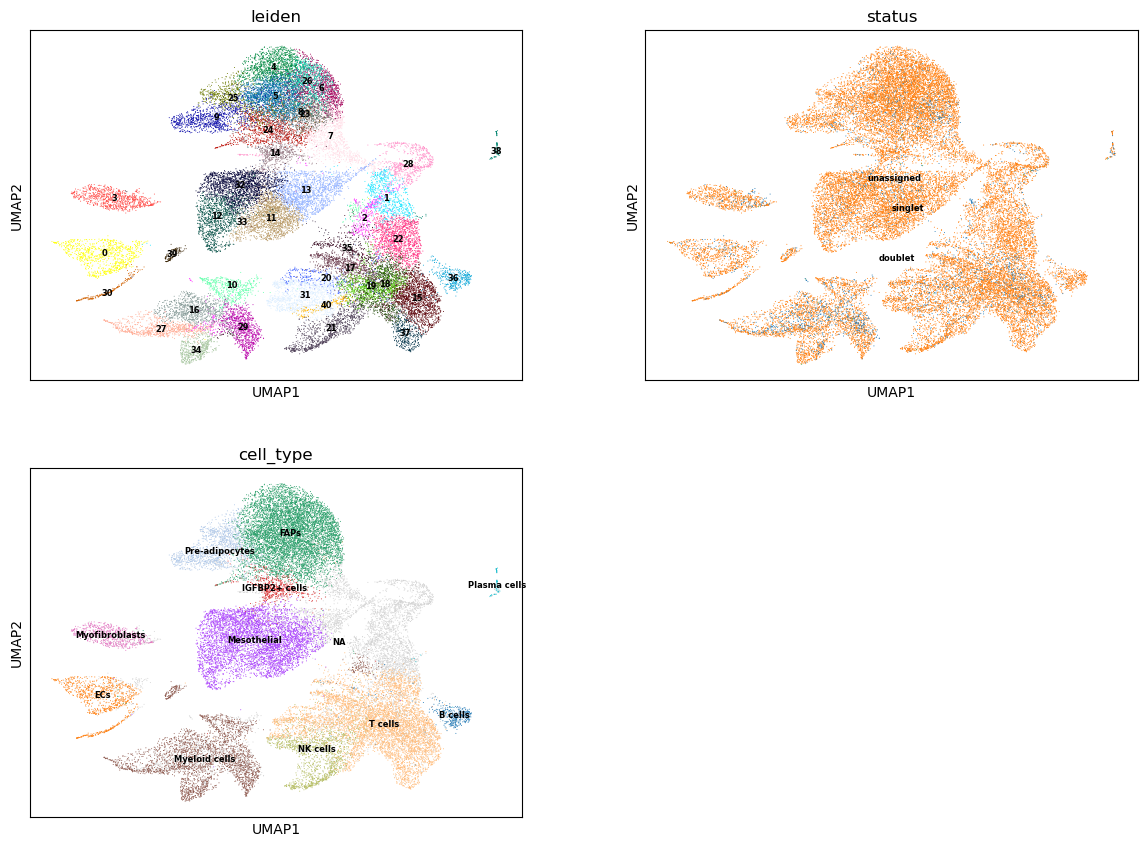

In [29]:
sc.pl.umap(adata_nan, color=["leiden", "status", "cell_type"], legend_loc="on data", legend_fontsize=6, ncols=2, size=2)

In [37]:
with pd.option_context('display.max_rows', 300):
    print(adata_nan.obs.value_counts(["leiden", "status", "scrublet_call"]).sort_index())

leiden  status      scrublet_call
0       doublet     False              63
                    True               23
        singlet     False             774
                    True               15
        unassigned  False               4
                    True                0
1       doublet     False              37
                    True                2
        singlet     False             643
                    True                1
        unassigned  False               0
                    True                0
2       doublet     False              48
                    True               14
        singlet     False             366
                    True                6
        unassigned  False               5
                    True                0
3       doublet     False              52
                    True               47
        singlet     False             722
                    True               14
        unassigned  False               2


In [40]:
cols = ["scrublet_score", "scrublet_call"]
adata_an.obs[cols] = adata_nan.obs.loc[adata_an.obs_names, cols].values

In [48]:
adata_an.obs["scrublet_call"] = adata_an.obs["scrublet_call"].astype(bool)
adata_an.obs["scrublet_score"] = adata_an.obs["scrublet_score"].astype(float)

In [52]:
import anndata as ad
ad.settings.allow_write_nullable_strings = True
adata_an.write_h5ad(os.path.join(INPUT_DIR, "anndatas", 'omentum_reannotated_finely.h5ad'))